# 13. Evaluación experimental del sistema de recomendación

En este notebook se amplía la evaluación del recomendador una vez terminadas las partes principales del sistema: preparación de los datos, análisis de Pareto, personalización y pruebas de robustez.

La idea aquí no es añadir modelos nuevos sin necesidad, sino comprobar un poco mejor **cómo se comporta el sistema** y qué aporta cada una de las partes que se han ido incorporando.

En concreto, se van a analizar:

1. la cobertura y calidad del dataset final;
2. la comparación con estrategias sencillas de referencia;
3. la distancia al punto ideal;
4. cómo cambian los resultados al modificar los pesos de precio y tiempo;
5. la estabilidad de las recomendaciones ante pequeños cambios en esos pesos;
6. la aportación de los distintos componentes del recomendador;
7. varios casos de uso con perfiles diferentes;
8. un resumen final con los resultados más importantes.


## 1. Importación de librerías y configuración

Primero se cargan las librerías necesarias para trabajar con los datos y generar los gráficos. Se utilizan principalmente `pandas`, `numpy` y `matplotlib`.


In [75]:
from pathlib import Path
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", 100)
pd.set_option("display.float_format", lambda x: f"{x:,.3f}")

RANDOM_STATE = 42

## 2. Carga automática del dataset final

Para no depender de un nombre de archivo concreto, se buscan los CSV disponibles dentro de `../data` y se intenta localizar automáticamente el que tiene las columnas necesarias para este análisis: zona, destino, tiempo de desplazamiento y alguna variable de precio.

Si el archivo está guardado en otra ruta, también se puede indicar directamente en `DATA_PATH`.


In [76]:
# El dataset final se generó en el notebook 07.
# Se prueban las dos rutas habituales según desde dónde se haya abierto Jupyter/VS Code.

DATA_CANDIDATES = [
    Path("data/final/neighborhood_recommender_dataset.csv"),
    Path("../data/final/neighborhood_recommender_dataset.csv"),
]

TIME_CANDIDATES = ["commute_minutes", "travel_time_minutes", "time_minutes"]
DESTINATION_CANDIDATES = ["destination_name", "destination", "destino"]
ZONE_CANDIDATES = ["zone_key", "neighborhood", "zone", "barrio"]
PRICE_CANDIDATES = ["sale_price_m2", "price_m2", "rent_price_m2"]


def first_existing(columns, candidates):
    for col in candidates:
        if col in columns:
            return col
    return None


# Primero se intenta cargar directamente el dataset final.
DATA_PATH = next((path for path in DATA_CANDIDATES if path.exists()), None)


# Si no aparece en esas rutas, se hace una búsqueda más general.
def score_csv(path):
    try:
        sample = pd.read_csv(path, nrows=5)
    except Exception:
        return -1

    cols = set(sample.columns)
    score = 0
    score += 3 if first_existing(cols, TIME_CANDIDATES) else 0
    score += 3 if first_existing(cols, DESTINATION_CANDIDATES) else 0
    score += 2 if first_existing(cols, ZONE_CANDIDATES) else 0
    score += 2 if any(c in cols for c in PRICE_CANDIDATES) else 0
    return score


if DATA_PATH is None:
    search_roots = [Path("data"), Path("../data")]
    csv_files = []

    for root in search_roots:
        if root.exists():
            csv_files.extend(root.rglob("*.csv"))

    # Se eliminan duplicados por si las dos rutas apuntan al mismo sitio.
    csv_files = list(dict.fromkeys(csv_files))

    scored = sorted(
        [(score_csv(path), path) for path in csv_files],
        key=lambda x: x[0],
        reverse=True,
    )

    if scored and scored[0][0] >= 8:
        DATA_PATH = scored[0][1]


if DATA_PATH is None:
    raise FileNotFoundError(
        "No se ha encontrado el dataset final. "
        "Comprueba que existe data/final/neighborhood_recommender_dataset.csv."
    )


print(f"Dataset seleccionado: {DATA_PATH.resolve()}")

df_raw = pd.read_csv(DATA_PATH)

print(f"Dimensiones: {df_raw.shape[0]:,} filas x {df_raw.shape[1]} columnas")


Dataset seleccionado: C:\Users\clave\OneDrive\Documentos\ASIGNATURAS 5º INF-ADE\TFG INFO\TFG_Recomendador_Viviendas\data\final\neighborhood_recommender_dataset.csv
Dimensiones: 393 filas x 140 columnas


### 2.1 Identificación de columnas

Como algunos nombres de columnas han ido cambiando durante el desarrollo del proyecto, el notebook intenta detectar automáticamente cuáles corresponden a las variables principales.


In [77]:
# El dataset final se generó en el notebook 07.
# Se prueban las dos rutas habituales según desde dónde se haya abierto Jupyter/VS Code.

DATA_CANDIDATES = [
    Path("data/final/neighborhood_recommender_dataset.csv"),
    Path("../data/final/neighborhood_recommender_dataset.csv"),
]

TIME_CANDIDATES = [
    "commute_daily_minutes",
    "commute_minutes",
    "travel_time_minutes",
    "time_minutes"
]

DESTINATION_CANDIDATES = [
    "destination_name",
    "destination",
    "destino"
]

ZONE_CANDIDATES = [
    "zone_key",
    "neighborhood",
    "zone",
    "barrio"
]

PRICE_CANDIDATES = [
    "price_m2_for_recommender",
    "sale_price_m2",
    "price_m2",
    "rent_price_m2"
]


def first_existing(columns, candidates):
    for col in candidates:
        if col in columns:
            return col
    return None


# Primero se intenta cargar directamente el dataset final.
DATA_PATH = next(
    (path for path in DATA_CANDIDATES if path.exists()),
    None
)


# Si no aparece en esas rutas, se hace una búsqueda más general.
def score_csv(path):
    try:
        sample = pd.read_csv(path, nrows=5)
    except Exception:
        return -1

    cols = set(sample.columns)

    score = 0
    score += 3 if first_existing(cols, TIME_CANDIDATES) else 0
    score += 3 if first_existing(cols, DESTINATION_CANDIDATES) else 0
    score += 2 if first_existing(cols, ZONE_CANDIDATES) else 0
    score += 2 if any(c in cols for c in PRICE_CANDIDATES) else 0

    return score


if DATA_PATH is None:
    search_roots = [
        Path("data"),
        Path("../data")
    ]

    csv_files = []

    for root in search_roots:
        if root.exists():
            csv_files.extend(root.rglob("*.csv"))

    # Se eliminan duplicados por si las dos rutas apuntan al mismo sitio.
    csv_files = list(dict.fromkeys(csv_files))

    scored = sorted(
        [(score_csv(path), path) for path in csv_files],
        key=lambda x: x[0],
        reverse=True,
    )

    if scored and scored[0][0] >= 8:
        DATA_PATH = scored[0][1]


if DATA_PATH is None:
    raise FileNotFoundError(
        "No se ha encontrado el dataset final. "
        "Comprueba que existe data/final/neighborhood_recommender_dataset.csv."
    )


print(f"Dataset seleccionado: {DATA_PATH.resolve()}")

df_raw = pd.read_csv(DATA_PATH)

print(
    f"Dimensiones: {df_raw.shape[0]:,} filas x "
    f"{df_raw.shape[1]} columnas"
)

Dataset seleccionado: C:\Users\clave\OneDrive\Documentos\ASIGNATURAS 5º INF-ADE\TFG INFO\TFG_Recomendador_Viviendas\data\final\neighborhood_recommender_dataset.csv
Dimensiones: 393 filas x 140 columnas


In [78]:
columns = set(df_raw.columns)

TIME_COL = first_existing(
    columns,
    TIME_CANDIDATES
)

DEST_COL = first_existing(
    columns,
    DESTINATION_CANDIDATES
)

ZONE_COL = first_existing(
    columns,
    ZONE_CANDIDATES
)

# Para mostrar el nombre del barrio si está disponible; si no, se usa zone_key.
LABEL_COL = first_existing(
    columns,
    [
        "neighborhood_name",
        "neighborhood",
        "barrio",
        "zone_name",
        "zone",
        ZONE_COL,
    ],
)

price_columns = [
    col for col in PRICE_CANDIDATES
    if col in columns
]

print("Columna de zona:", ZONE_COL)
print("Etiqueta de zona:", LABEL_COL)
print("Columna de destino:", DEST_COL)
print("Columna de tiempo:", TIME_COL)
print("Variables de precio disponibles:", price_columns)


required = [
    TIME_COL,
    DEST_COL,
    ZONE_COL
]

if any(col is None for col in required) or not price_columns:
    raise ValueError(
        "Faltan columnas necesarias. Revisa los nombres detectados y añade "
        "el nombre correcto a las listas de candidatos de la celda anterior."
    )

Columna de zona: zone_key
Etiqueta de zona: neighborhood_name
Columna de destino: destination_name
Columna de tiempo: commute_daily_minutes
Variables de precio disponibles: ['price_m2_for_recommender']


## 3. Cobertura y calidad del dataset

Antes de analizar las recomendaciones, se revisa cuánta información útil tenemos realmente en el dataset.

Los casos en los que no se ha podido obtener una ruta se mantienen como valores ausentes. Se ha preferido no inventar ni estimar esos tiempos, ya que el desplazamiento es una de las variables principales del recomendador y una imputación podría acabar afectando al resultado.


In [79]:
coverage_summary = pd.DataFrame({
    "metric": [
        "Filas totales",
        "Zonas únicas",
        "Destinos únicos",
        "Filas con tiempo válido",
        "Filas sin ruta/tiempo",
        "Cobertura de rutas (%)",
    ],
    "value": [
        len(df_raw),
        df_raw[ZONE_COL].nunique(dropna=True),
        df_raw[DEST_COL].nunique(dropna=True),
        df_raw[TIME_COL].notna().sum(),
        df_raw[TIME_COL].isna().sum(),
        100 * df_raw[TIME_COL].notna().mean(),
    ],
})

coverage_summary

,metric,value
0,Filas totales,393.000
1,Zonas únicas,131.000
2,Destinos únicos,3.000
3,Filas con tiempo válido,373.000
4,Filas sin ruta/tiempo,20.000
5,Cobertura de rutas (%),94.911


In [80]:
missing_by_destination = (
    df_raw.groupby(DEST_COL, dropna=False)
    .agg(
        alternatives=(ZONE_COL, "nunique"),
        valid_routes=(TIME_COL, lambda s: s.notna().sum()),
        missing_routes=(TIME_COL, lambda s: s.isna().sum()),
    )
    .reset_index()
)

missing_by_destination["route_coverage_pct"] = (
    100 * missing_by_destination["valid_routes"]
    / (missing_by_destination["valid_routes"] + missing_by_destination["missing_routes"])
)

missing_by_destination.sort_values("route_coverage_pct").head(15)

,destination_name,alternatives,valid_routes,missing_routes,route_coverage_pct
1,Puerta del Sol,131,120,11,91.603
0,Nuevos Ministerios,131,125,6,95.420
2,UC3M Campus de Leganés,131,128,3,97.710


## 4. Funciones auxiliares de evaluación

A continuación se definen algunas funciones que se van a reutilizar durante el notebook para no repetir cálculos.

- **Normalización min-max:** lleva precio y tiempo a una escala entre 0 y 1 para poder compararlos.
- **Dominancia de Pareto:** permite identificar las alternativas que no están claramente superadas por otra en precio y tiempo.
- **Puntuación ponderada:** combina ambos criterios según la importancia que les dé el usuario. Cuanto menor sea la puntuación, mejor.
- **Distancia al punto ideal:** indica lo cerca que está cada alternativa de combinar un precio bajo y un tiempo bajo al mismo tiempo.


In [81]:
def minmax(series):
    s = pd.to_numeric(series, errors="coerce")
    min_v = s.min()
    max_v = s.max()
    if pd.isna(min_v) or pd.isna(max_v):
        return pd.Series(np.nan, index=s.index)
    if np.isclose(max_v, min_v):
        return pd.Series(0.0, index=s.index)
    return (s - min_v) / (max_v - min_v)


def pareto_mask(values):
    """Devuelve True para las soluciones no dominadas en un problema de minimización."""
    values = np.asarray(values, dtype=float)
    n = len(values)
    efficient = np.ones(n, dtype=bool)

    for i in range(n):
        if not efficient[i]:
            continue
        dominated_by_any = np.all(values <= values[i], axis=1) & np.any(values < values[i], axis=1)
        if dominated_by_any.any():
            efficient[i] = False

    return efficient


def prepare_destination(data, destination, price_col):
    subset = data.loc[data[DEST_COL] == destination].copy()
    subset[price_col] = pd.to_numeric(subset[price_col], errors="coerce")
    subset[TIME_COL] = pd.to_numeric(subset[TIME_COL], errors="coerce")
    subset = subset.dropna(subset=[price_col, TIME_COL, ZONE_COL]).copy()

    subset["price_norm"] = minmax(subset[price_col])
    subset["time_norm"] = minmax(subset[TIME_COL])
    subset["ideal_distance"] = np.sqrt(
        subset["price_norm"] ** 2 + subset["time_norm"] ** 2
    )
    subset["is_pareto"] = pareto_mask(subset[[price_col, TIME_COL]].to_numpy())
    return subset


def rank_weighted(subset, price_col, price_weight=0.5, pareto_only=False):
    if not 0 <= price_weight <= 1:
        raise ValueError("price_weight debe estar entre 0 y 1.")

    ranked = subset.copy()
    if pareto_only:
        ranked = ranked.loc[ranked["is_pareto"]].copy()

    time_weight = 1 - price_weight
    ranked["weighted_score"] = (
        price_weight * ranked["price_norm"]
        + time_weight * ranked["time_norm"]
    )

    return ranked.sort_values(
        ["weighted_score", "ideal_distance", price_col, TIME_COL],
        ascending=True,
    )

## 5. Variable de precio utilizada

Una vez identificadas las columnas necesarias, se selecciona la variable de precio utilizada por el recomendador.

En el dataset final esta variable corresponde a `price_m2_for_recommender`. A partir de ella y del tiempo de desplazamiento se realizan los distintos análisis del notebook.

In [82]:
PRICE_COL = price_columns[0]
print(f"Variable de precio utilizada: {PRICE_COL}")

valid_destinations = (
    df_raw.dropna(subset=[PRICE_COL, TIME_COL, DEST_COL])[DEST_COL]
    .drop_duplicates()
    .tolist()
)

print(f"Destinos con información válida: {len(valid_destinations)}")
print(valid_destinations[:10])

Variable de precio utilizada: price_m2_for_recommender
Destinos con información válida: 3
['Nuevos Ministerios', 'UC3M Campus de Leganés', 'Puerta del Sol']


## 6. Comparación con estrategias simples (*baselines*)

Para tener una referencia con la que comparar el recomendador, se prueban cuatro formas sencillas de elegir una zona:

- **Más barata:** se queda únicamente con la alternativa de menor precio.
- **Más rápida:** se queda con la que tiene menor tiempo de desplazamiento.
- **Equilibrada 50/50:** da la misma importancia al precio y al tiempo.
- **Pareto + 50/50:** primero elimina las alternativas dominadas y después aplica el mismo reparto 50/50.

Con esto se puede ver qué diferencia hay entre utilizar el sistema completo y tomar decisiones mucho más simples.


In [83]:
def baseline_comparison(data, price_col):
    rows = []

    for destination in valid_destinations:
        subset = prepare_destination(data, destination, price_col)
        if subset.empty:
            continue

        strategies = {
            "Más barata": subset.sort_values([price_col, TIME_COL]).iloc[0],
            "Más rápida": subset.sort_values([TIME_COL, price_col]).iloc[0],
            "Equilibrada 50/50": rank_weighted(subset, price_col, 0.5, False).iloc[0],
            "Pareto + 50/50": rank_weighted(subset, price_col, 0.5, True).iloc[0],
        }

        for strategy, winner in strategies.items():
            rows.append({
                DEST_COL: destination,
                "strategy": strategy,
                "zone": winner[LABEL_COL],
                "zone_key": winner[ZONE_COL],
                "price": winner[price_col],
                "commute_minutes": winner[TIME_COL],
                "ideal_distance": winner["ideal_distance"],
                "is_pareto": bool(winner["is_pareto"]),
            })

    return pd.DataFrame(rows)


baseline_results = baseline_comparison(df_raw, PRICE_COL)
baseline_results.head(12)

,destination_name,strategy,zone,zone_key,price,commute_minutes,ideal_distance,is_pareto
0,Nuevos Ministerios,Más barata,San Cristóbal,MAD-172,"1,909.600",174.283,0.560,True
1,Nuevos Ministerios,Más rápida,Almagro,MAD-074,"10,795.410",44.967,0.728,True
2,Nuevos Ministerios,Equilibrada 50/50,Bellas Vistas,MAD-061,"5,223.920",49.800,0.272,True
3,Nuevos Ministerios,Pareto + 50/50,Bellas Vistas,MAD-061,"5,223.920",49.800,0.272,True
4,UC3M Campus de Leganés,Más barata,San Cristóbal,MAD-172,"1,909.600",136.333,0.306,True
5,UC3M Campus de Leganés,Más rápida,Buenavista,MAD-116,"3,291.570",51.617,0.113,True
6,UC3M Campus de Leganés,Equilibrada 50/50,Buenavista,MAD-116,"3,291.570",51.617,0.113,True
7,UC3M Campus de Leganés,Pareto + 50/50,Buenavista,MAD-116,"3,291.570",51.617,0.113,True
8,Puerta del Sol,Más barata,San Cristóbal,MAD-172,"1,909.600",139.717,0.443,True
9,Puerta del Sol,Más rápida,Recoletos,MAD-041,"14,108.830",56.367,1.000,True


In [84]:
baseline_summary = (
    baseline_results.groupby("strategy")
    .agg(
        mean_price=("price", "mean"),
        mean_commute_minutes=("commute_minutes", "mean"),
        mean_ideal_distance=("ideal_distance", "mean"),
        pareto_rate=("is_pareto", "mean"),
    )
    .reset_index()
)

baseline_summary["pareto_rate"] *= 100
baseline_summary.sort_values("mean_ideal_distance")

,strategy,mean_price,mean_commute_minutes,mean_ideal_distance,pareto_rate
0,Equilibrada 50/50,"4,182.930",55.517,0.189,100.000
3,Pareto + 50/50,"4,182.930",55.517,0.189,100.000
1,Más barata,"1,909.600",150.111,0.436,100.000
2,Más rápida,"9,398.603",50.983,0.614,100.000


### 6.1 ¿Cambia el ganador al aplicar Pareto?

También se comprueba si el resultado final cambia al filtrar primero las alternativas con Pareto.

Puede ocurrir que el ganador sea exactamente el mismo. Esto es normal: si una zona es peor que otra tanto en precio como en tiempo, tampoco debería acabar ganando cuando se combinan ambos criterios con pesos positivos.

Por tanto, Pareto no tiene por qué cambiar siempre la primera recomendación. Su utilidad está sobre todo en quitar alternativas poco interesantes y dejar un conjunto de opciones que representan compromisos razonables entre precio y desplazamiento.


In [85]:
wide = baseline_results.pivot(index=DEST_COL, columns="strategy", values="zone_key")

if {"Equilibrada 50/50", "Pareto + 50/50"}.issubset(wide.columns):
    same_winner_rate = 100 * (
        wide["Equilibrada 50/50"] == wide["Pareto + 50/50"]
    ).mean()
    print(f"Coincidencia de ganador con y sin filtro Pareto: {same_winner_rate:.2f} %")

Coincidencia de ganador con y sin filtro Pareto: 100.00 %


## 7. Distancia al punto ideal

Dentro del frente de Pareto puede haber varias alternativas interesantes y no siempre existe una única opción claramente mejor.

Como referencia adicional, se calcula la distancia de cada alternativa al llamado **punto ideal**, que representaría tener al mismo tiempo el precio más bajo y el menor tiempo de desplazamiento.

Ese punto normalmente no corresponde a una zona real, pero sirve para localizar cuál de las alternativas se acerca más a ese equilibrio.


In [86]:
ideal_rows = []

for destination in valid_destinations:
    subset = prepare_destination(df_raw, destination, PRICE_COL)
    if subset.empty:
        continue

    winner = (
        subset.loc[subset["is_pareto"]]
        .sort_values(["ideal_distance", PRICE_COL, TIME_COL])
        .iloc[0]
    )

    ideal_rows.append({
        DEST_COL: destination,
        "zone": winner[LABEL_COL],
        "zone_key": winner[ZONE_COL],
        "price": winner[PRICE_COL],
        "commute_minutes": winner[TIME_COL],
        "ideal_distance": winner["ideal_distance"],
    })

ideal_results = pd.DataFrame(ideal_rows)
ideal_results.sort_values("ideal_distance").head(15)

,destination_name,zone,zone_key,price,commute_minutes,ideal_distance
1,UC3M Campus de Leganés,Buenavista,MAD-116,"3,291.570",51.617,0.113
2,Puerta del Sol,Puerta del Ángel,MAD-102,"4,033.300",65.133,0.180
0,Nuevos Ministerios,Rejas,MAD-206,"3,580.160",82.267,0.212


### 7.1 Visualización para un destino

En el siguiente gráfico se representa la relación entre precio y tiempo para un destino concreto.

También se muestran las alternativas que forman parte del frente de Pareto y se marca la que queda más cerca del punto ideal. Así se puede ver de forma bastante directa el compromiso entre pagar menos y tardar menos.


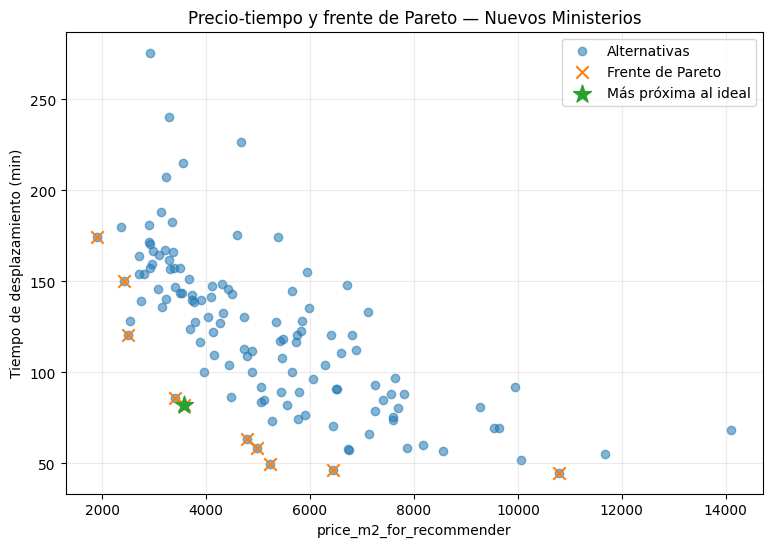

Solución de compromiso: Rejas | 3,580.16 | 82.27 min


In [87]:
DESTINATION_EXAMPLE = valid_destinations[0]
subset_example = prepare_destination(df_raw, DESTINATION_EXAMPLE, PRICE_COL)

plt.figure(figsize=(9, 6))
plt.scatter(
    subset_example[PRICE_COL],
    subset_example[TIME_COL],
    alpha=0.55,
    label="Alternativas",
)

pareto_example = subset_example.loc[subset_example["is_pareto"]]
plt.scatter(
    pareto_example[PRICE_COL],
    pareto_example[TIME_COL],
    marker="x",
    s=80,
    label="Frente de Pareto",
)

ideal_winner = pareto_example.sort_values("ideal_distance").iloc[0]
plt.scatter(
    [ideal_winner[PRICE_COL]],
    [ideal_winner[TIME_COL]],
    marker="*",
    s=180,
    label="Más próxima al ideal",
)

plt.xlabel(PRICE_COL)
plt.ylabel("Tiempo de desplazamiento (min)")
plt.title(f"Precio-tiempo y frente de Pareto — {DESTINATION_EXAMPLE}")
plt.legend()
plt.grid(alpha=0.25)
plt.show()

print(
    f"Solución de compromiso: {ideal_winner[LABEL_COL]} | "
    f"{ideal_winner[PRICE_COL]:,.2f} | "
    f"{ideal_winner[TIME_COL]:.2f} min"
)

## 8. Sensibilidad a las preferencias del usuario

Una parte importante del recomendador es que el resultado dependa de lo que valore más cada usuario.

Para comprobar cómo cambia la recomendación, se modifica poco a poco el peso del precio desde 0 hasta 1. El peso del tiempo se calcula como el valor restante.

Con este análisis se puede ver:

- cuántas zonas distintas llegan a aparecer como primera opción;
- en qué momento cambia la recomendación;
- qué alternativas se mantienen durante un rango mayor de preferencias.


In [88]:
def weight_sensitivity(data, destination, price_col, step=0.05):
    subset = prepare_destination(data, destination, price_col)
    weights = np.round(np.arange(0, 1 + step / 2, step), 4)
    rows = []

    for w_price in weights:
        ranked = rank_weighted(subset, price_col, w_price, pareto_only=True)
        if ranked.empty:
            continue
        winner = ranked.iloc[0]
        rows.append({
            "price_weight": w_price,
            "time_weight": 1 - w_price,
            "zone": winner[LABEL_COL],
            "zone_key": winner[ZONE_COL],
            "price": winner[price_col],
            "commute_minutes": winner[TIME_COL],
            "weighted_score": winner["weighted_score"],
        })

    result = pd.DataFrame(rows)
    result["winner_change"] = result["zone_key"].ne(result["zone_key"].shift())
    return result


sensitivity_example = weight_sensitivity(df_raw, DESTINATION_EXAMPLE, PRICE_COL)
sensitivity_example

,price_weight,time_weight,zone,zone_key,price,commute_minutes,weighted_score,winner_change
0,0.000,1.000,Almagro,MAD-074,"10,795.410",44.967,0.000,True
1,0.050,0.950,Castillejos,MAD-063,"6,438.000",46.617,0.025,True
2,0.100,0.900,Castillejos,MAD-063,"6,438.000",46.617,0.044,False
3,0.150,0.850,Bellas Vistas,MAD-061,"5,223.920",49.800,0.059,True
4,0.200,0.800,Bellas Vistas,MAD-061,"5,223.920",49.800,0.071,False
5,0.250,0.750,Bellas Vistas,MAD-061,"5,223.920",49.800,0.084,False
6,0.300,0.700,Bellas Vistas,MAD-061,"5,223.920",49.800,0.096,False
7,0.350,0.650,Bellas Vistas,MAD-061,"5,223.920",49.800,0.109,False
8,0.400,0.600,Bellas Vistas,MAD-061,"5,223.920",49.800,0.121,False
9,0.450,0.550,Bellas Vistas,MAD-061,"5,223.920",49.800,0.134,False


In [89]:
changes = sensitivity_example.loc[sensitivity_example["winner_change"]].copy()

print(f"Destino: {DESTINATION_EXAMPLE}")
print(f"Ganadores distintos: {sensitivity_example['zone_key'].nunique()}")
print(f"Cambios de ganador: {max(len(changes) - 1, 0)}")

display(changes[["price_weight", "time_weight", "zone", "price", "commute_minutes"]])

Destino: Nuevos Ministerios
Ganadores distintos: 6
Cambios de ganador: 5


,price_weight,time_weight,zone,price,commute_minutes
0,0.000,1.000,Almagro,"10,795.410",44.967
1,0.050,0.950,Castillejos,"6,438.000",46.617
3,0.150,0.850,Bellas Vistas,"5,223.920",49.800
11,0.550,0.450,Canillejas,"3,409.640",86.017
14,0.700,0.300,Hellín,"2,498.860",120.650
17,0.850,0.150,San Cristóbal,"1,909.600",174.283


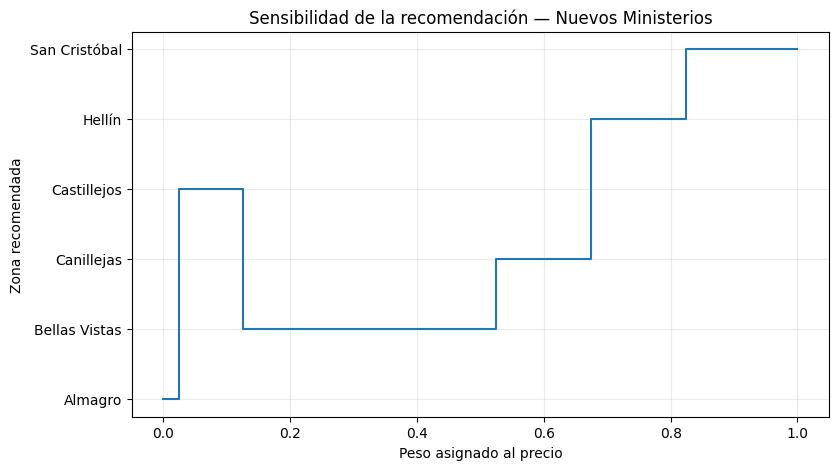

In [90]:
plt.figure(figsize=(9, 5))

zone_codes = pd.Categorical(sensitivity_example["zone"]).codes
plt.step(
    sensitivity_example["price_weight"],
    zone_codes,
    where="mid",
)

plt.yticks(
    range(len(pd.Categorical(sensitivity_example["zone"]).categories)),
    pd.Categorical(sensitivity_example["zone"]).categories,
)
plt.xlabel("Peso asignado al precio")
plt.ylabel("Zona recomendada")
plt.title(f"Sensibilidad de la recomendación — {DESTINATION_EXAMPLE}")
plt.grid(alpha=0.25)
plt.show()

### 8.1 Resumen de sensibilidad para todos los destinos

El comportamiento puede ser diferente según el destino.

En algunos casos una misma zona puede mantenerse como ganadora aunque los pesos cambien bastante, mientras que en otros pueden aparecer varias alternativas a medida que cambia la importancia del precio y del tiempo.


In [91]:
sensitivity_summary_rows = []

for destination in valid_destinations:
    sens = weight_sensitivity(df_raw, destination, PRICE_COL)
    if sens.empty:
        continue

    sensitivity_summary_rows.append({
        DEST_COL: destination,
        "unique_winners": sens["zone_key"].nunique(),
        "winner_changes": max(int(sens["winner_change"].sum()) - 1, 0),
        "most_frequent_winner": sens["zone"].mode().iloc[0],
        "most_frequent_winner_share_pct": 100 * sens["zone"].value_counts(normalize=True).iloc[0],
    })

sensitivity_summary = pd.DataFrame(sensitivity_summary_rows)
sensitivity_summary.sort_values(["unique_winners", "winner_changes"], ascending=False).head(15)

,destination_name,unique_winners,winner_changes,most_frequent_winner,most_frequent_winner_share_pct
0,Nuevos Ministerios,6,5,Bellas Vistas,38.095
2,Puerta del Sol,4,3,Puerta del Ángel,52.381
1,UC3M Campus de Leganés,2,1,Buenavista,71.429


## 9. Estabilidad local de la recomendación

Además de recorrer todos los posibles pesos, también interesa comprobar qué ocurre cuando el usuario cambia solo un poco sus preferencias.

Para ello se parte de una configuración equilibrada y se modifica el peso del precio en ±5 puntos porcentuales.

Este análisis es distinto al de robustez realizado anteriormente. Allí se modificaban ligeramente los datos de precio y tiempo; aquí los datos se mantienen iguales y lo único que cambia es **la prioridad indicada por el usuario**.


In [92]:
def local_preference_stability(data, price_col, base_weight=0.5, delta=0.05):
    test_weights = [
        max(0, base_weight - delta),
        base_weight,
        min(1, base_weight + delta),
    ]

    rows = []
    for destination in valid_destinations:
        subset = prepare_destination(data, destination, price_col)
        winners = []

        for w in test_weights:
            ranked = rank_weighted(subset, price_col, w, pareto_only=True)
            winners.append(ranked.iloc[0][ZONE_COL])

        rows.append({
            DEST_COL: destination,
            "weight_low": test_weights[0],
            "weight_base": test_weights[1],
            "weight_high": test_weights[2],
            "same_winner_all": len(set(winners)) == 1,
            "distinct_winners": len(set(winners)),
        })

    return pd.DataFrame(rows)


local_stability = local_preference_stability(df_raw, PRICE_COL, base_weight=0.5, delta=0.05)

print(
    "Destinos con el mismo ganador ante ±5 puntos de peso: "
    f"{100 * local_stability['same_winner_all'].mean():.2f} %"
)

local_stability.head(10)

Destinos con el mismo ganador ante ±5 puntos de peso: 66.67 %


,destination_name,weight_low,weight_base,weight_high,same_winner_all,distinct_winners
0,Nuevos Ministerios,0.450,0.500,0.550,False,2
1,UC3M Campus de Leganés,0.450,0.500,0.550,True,1
2,Puerta del Sol,0.450,0.500,0.550,True,1


## 10. Análisis de contribución de componentes

En esta parte se comparan versiones más simples del sistema para entender qué aporta cada componente.

Se utilizan:

1. solo precio;
2. solo tiempo de transporte;
3. combinación ponderada de precio y tiempo;
4. Pareto seguido de la combinación ponderada;
5. selección según la distancia al punto ideal.

No se espera necesariamente que todas den un resultado diferente. Lo que interesa es comprobar cómo cambia la decisión y entender mejor el papel de cada parte del recomendador.


In [93]:
def component_analysis(data, price_col, price_weight=0.5):
    rows = []

    for destination in valid_destinations:
        subset = prepare_destination(data, destination, price_col)
        if subset.empty:
            continue

        candidates = {
            "Solo precio": subset.sort_values([price_col, TIME_COL]).iloc[0],
            "Solo transporte": subset.sort_values([TIME_COL, price_col]).iloc[0],
            "Ponderación sin Pareto": rank_weighted(subset, price_col, price_weight, False).iloc[0],
            "Pareto + ponderación": rank_weighted(subset, price_col, price_weight, True).iloc[0],
            "Pareto + punto ideal": subset.loc[subset["is_pareto"]]
                .sort_values(["ideal_distance", price_col, TIME_COL])
                .iloc[0],
        }

        for component, winner in candidates.items():
            rows.append({
                DEST_COL: destination,
                "configuration": component,
                "zone": winner[LABEL_COL],
                "zone_key": winner[ZONE_COL],
                "price": winner[price_col],
                "commute_minutes": winner[TIME_COL],
                "ideal_distance": winner["ideal_distance"],
                "is_pareto": bool(winner["is_pareto"]),
            })

    return pd.DataFrame(rows)


component_results = component_analysis(df_raw, PRICE_COL, price_weight=0.5)

component_summary = (
    component_results.groupby("configuration")
    .agg(
        mean_price=("price", "mean"),
        mean_commute_minutes=("commute_minutes", "mean"),
        mean_ideal_distance=("ideal_distance", "mean"),
        pareto_rate=("is_pareto", "mean"),
    )
    .reset_index()
)
component_summary["pareto_rate"] *= 100
component_summary.sort_values("mean_ideal_distance")

,configuration,mean_price,mean_commute_minutes,mean_ideal_distance,pareto_rate
1,Pareto + punto ideal,"3,635.010",66.339,0.168,100.000
0,Pareto + ponderación,"4,182.930",55.517,0.189,100.000
2,Ponderación sin Pareto,"4,182.930",55.517,0.189,100.000
3,Solo precio,"1,909.600",150.111,0.436,100.000
4,Solo transporte,"9,398.603",50.983,0.614,100.000


## 11. Casos de uso con perfiles de usuario

Para acercar un poco más la evaluación al uso real de la aplicación, se utilizan los mismos tres perfiles definidos en los análisis anteriores:

- **Estudiante:** 80 % precio y 20 % tiempo.
- **Equilibrado:** 50 % precio y 50 % tiempo.
- **Profesional:** 25 % precio y 75 % tiempo.

Estos perfiles representan distintas formas de repartir la importancia entre el precio de la vivienda y el tiempo de desplazamiento. No se pretende que todos los usuarios encajen exactamente en uno de ellos, sino utilizarlos como ejemplos para comprobar cómo cambian las recomendaciones según las prioridades.

Para cada destino se muestran las cinco primeras alternativas obtenidas para cada perfil.

In [94]:
PROFILES = {
    "Estudiante": 0.80,
    "Equilibrado": 0.50,
    "Profesional": 0.25,
}

CASE_DESTINATIONS = valid_destinations

case_rows = []

for destination in CASE_DESTINATIONS:
    subset = prepare_destination(df_raw, destination, PRICE_COL)

    for profile_name, price_weight in PROFILES.items():
        ranked = rank_weighted(
            subset,
            PRICE_COL,
            price_weight=price_weight,
            pareto_only=True,
        ).head(5)

        for rank, (_, row) in enumerate(ranked.iterrows(), start=1):
            case_rows.append({
                DEST_COL: destination,
                "profile": profile_name,
                "rank": rank,
                "zone": row[LABEL_COL],
                "price": row[PRICE_COL],
                "commute_minutes": row[TIME_COL],
                "score": row["weighted_score"],
            })

case_results = pd.DataFrame(case_rows)
case_results

,destination_name,profile,rank,zone,price,commute_minutes,score
0,Nuevos Ministerios,Estudiante,1,Hellín,"2,498.860",120.650,0.104
1,Nuevos Ministerios,Estudiante,2,San Cristóbal,"1,909.600",174.283,0.112
2,Nuevos Ministerios,Estudiante,3,Entrevías,"2,430.160",150.167,0.125
3,Nuevos Ministerios,Estudiante,4,Canillejas,"3,409.640",86.017,0.134
4,Nuevos Ministerios,Estudiante,5,Rejas,"3,580.160",82.267,0.142
5,Nuevos Ministerios,Equilibrado,1,Bellas Vistas,"5,223.920",49.800,0.146
6,Nuevos Ministerios,Equilibrado,2,Rejas,"3,580.160",82.267,0.149
7,Nuevos Ministerios,Equilibrado,3,Canillejas,"3,409.640",86.017,0.150
8,Nuevos Ministerios,Equilibrado,4,Almenara,"4,987.490",58.550,0.156
9,Nuevos Ministerios,Equilibrado,5,Berruguete,"4,789.990",63.350,0.158


### 11.1 Ganador por perfil

La siguiente tabla recoge únicamente la zona que queda en primera posición para cada perfil y destino.

Esto permite comprobar de forma sencilla cómo cambian las recomendaciones según las prioridades. Al aumentar el peso del precio aparecen alternativas más económicas, mientras que al dar más importancia al transporte ganan peso las zonas con tiempos de desplazamiento menores.

In [95]:
case_winners = case_results.loc[case_results["rank"] == 1].copy()
case_winners.sort_values([DEST_COL, "profile"])

,destination_name,profile,rank,zone,price,commute_minutes,score
5,Nuevos Ministerios,Equilibrado,1,Bellas Vistas,"5,223.920",49.800,0.146
0,Nuevos Ministerios,Estudiante,1,Hellín,"2,498.860",120.650,0.104
10,Nuevos Ministerios,Profesional,1,Bellas Vistas,"5,223.920",49.800,0.084
35,Puerta del Sol,Equilibrado,1,Puerta del Ángel,"4,033.300",65.133,0.110
30,Puerta del Sol,Estudiante,1,San Cristóbal,"1,909.600",139.717,0.089
40,Puerta del Sol,Profesional,1,Puerta del Ángel,"4,033.300",65.133,0.078
20,UC3M Campus de Leganés,Equilibrado,1,Buenavista,"3,291.570",51.617,0.057
15,UC3M Campus de Leganés,Estudiante,1,San Cristóbal,"1,909.600",136.333,0.061
25,UC3M Campus de Leganés,Profesional,1,Buenavista,"3,291.570",51.617,0.028


## 12. Indicadores globales para la memoria

Para terminar el análisis se reúnen algunos indicadores generales que resumen los resultados obtenidos.

Estos valores pueden ser útiles más adelante para presentar de forma compacta los resultados en la memoria del TFG.


In [96]:
pareto_counts = []

for destination in valid_destinations:
    subset = prepare_destination(df_raw, destination, PRICE_COL)
    if subset.empty:
        continue
    pareto_counts.append({
        DEST_COL: destination,
        "alternatives": len(subset),
        "pareto_alternatives": int(subset["is_pareto"].sum()),
        "pareto_pct": 100 * subset["is_pareto"].mean(),
    })

pareto_counts = pd.DataFrame(pareto_counts)

final_metrics = pd.DataFrame({
    "indicator": [
        "Cobertura global de rutas (%)",
        "Alternativas medias por destino",
        "Alternativas Pareto medias por destino",
        "Porcentaje Pareto medio (%)",
        "Coincidencia 50/50 con y sin Pareto (%)",
        "Estabilidad ante ±5 puntos de peso (%)",
        "Ganadores distintos medios al variar pesos",
    ],
    "value": [
        100 * df_raw[TIME_COL].notna().mean(),
        pareto_counts["alternatives"].mean(),
        pareto_counts["pareto_alternatives"].mean(),
        pareto_counts["pareto_pct"].mean(),
        same_winner_rate if "same_winner_rate" in globals() else np.nan,
        100 * local_stability["same_winner_all"].mean(),
        sensitivity_summary["unique_winners"].mean(),
    ],
})

final_metrics

,indicator,value
0,Cobertura global de rutas (%),94.911
1,Alternativas medias por destino,123.667
2,Alternativas Pareto medias por destino,9.333
3,Porcentaje Pareto medio (%),7.632
4,Coincidencia 50/50 con y sin Pareto (%),100.000
5,Estabilidad ante ±5 puntos de peso (%),66.667
6,Ganadores distintos medios al variar pesos,4.000


## 13. Exportación de resultados

Los resultados principales se guardan en una carpeta separada para poder reutilizarlos después sin tener que volver a ejecutar todos los análisis.

De esta forma se podrán utilizar fácilmente en la memoria, en la aplicación o en cualquier comprobación posterior.


In [97]:
OUTPUT_DIR = Path("../data/results/evaluation")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

coverage_summary.to_csv(OUTPUT_DIR / "coverage_summary.csv", index=False)
missing_by_destination.to_csv(OUTPUT_DIR / "route_coverage_by_destination.csv", index=False)
baseline_results.to_csv(OUTPUT_DIR / "baseline_results.csv", index=False)
baseline_summary.to_csv(OUTPUT_DIR / "baseline_summary.csv", index=False)
ideal_results.to_csv(OUTPUT_DIR / "ideal_point_results.csv", index=False)
sensitivity_summary.to_csv(OUTPUT_DIR / "weight_sensitivity_summary.csv", index=False)
local_stability.to_csv(OUTPUT_DIR / "local_preference_stability.csv", index=False)
component_results.to_csv(OUTPUT_DIR / "component_analysis.csv", index=False)
case_results.to_csv(OUTPUT_DIR / "case_studies.csv", index=False)
final_metrics.to_csv(OUTPUT_DIR / "final_evaluation_metrics.csv", index=False)

print(f"Resultados guardados en: {OUTPUT_DIR.resolve()}")

Resultados guardados en: C:\Users\clave\OneDrive\Documentos\ASIGNATURAS 5º INF-ADE\TFG INFO\TFG_Recomendador_Viviendas\data\results\evaluation


## 14. Interpretación de la evaluación

En este problema no existe una única zona que pueda considerarse correcta para todos los usuarios, ya que la elección depende de las preferencias que cada persona tenga sobre el precio y el tiempo de desplazamiento.

Por este motivo, la evaluación no se basa en métricas habituales de predicción como accuracy, MAE o RMSE. En su lugar, se analiza si las recomendaciones son eficientes desde el punto de vista multiobjetivo, cómo cambian al modificar las preferencias y hasta qué punto se mantienen estables ante pequeñas variaciones.

Los distintos análisis realizados permiten así comprobar no solo qué zonas recomienda el sistema, sino también si las recomendaciones siguen un comportamiento coherente con los criterios utilizados.

## 15. Conclusiones de la evaluación experimental

La evaluación realizada permite comprobar el comportamiento del recomendador desde varios puntos de vista, más allá de obtener simplemente una lista ordenada de zonas.

En primer lugar, el dataset presenta una cobertura global de rutas del **94,91 %**, por lo que se dispone de información válida de transporte para la gran mayoría de las alternativas. Además, solo alrededor del **7,63 %** de las zonas válidas forman parte del frente de Pareto, lo que permite reducir bastante el conjunto inicial y centrarse en aquellas alternativas que ofrecen compromisos eficientes entre precio y tiempo de desplazamiento.

La comparación con estrategias más simples muestra también bastante bien el problema que se quiere resolver. Elegir únicamente por precio lleva a alternativas muy económicas pero con desplazamientos mucho más largos, mientras que priorizar solo el transporte reduce el tiempo a costa de precios bastante mayores. Las soluciones que combinan ambos criterios se sitúan en posiciones más intermedias.

El análisis de sensibilidad confirma además que las preferencias del usuario tienen un efecto real sobre el resultado. Al variar progresivamente los pesos aparecen una media de **cuatro zonas ganadoras diferentes por destino**, aunque este comportamiento cambia según el destino analizado.

Por otro lado, al modificar únicamente ±5 puntos porcentuales los pesos alrededor del perfil equilibrado, el ganador se mantiene en el **66,67 % de los destinos**. Esto indica que las recomendaciones presentan cierta estabilidad, pero también son capaces de cambiar cuando las preferencias del usuario pasan a favorecer otra alternativa.

Por último, se ha comprobado que aplicar Pareto antes de la ponderación no cambia necesariamente el ganador final. Su utilidad está principalmente en eliminar alternativas dominadas y trabajar con un conjunto más reducido e interpretable de soluciones eficientes.

En conjunto, estos resultados complementan los análisis realizados en los notebooks anteriores y permiten comprobar que el sistema responde de forma coherente tanto al conflicto entre precio y desplazamiento como a los cambios en las preferencias del usuario.